<a href="https://colab.research.google.com/github/Oldmanne13/Student_dropout/blob/main/Student_dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Indlæs filen
df = pd.read_csv('student_dropout_dataset_v3.csv')

#df = pd.read_csv('student_dropout_dataset_v3.csv'sep=';',           # Semikolon som separatodecimal=',',       # Komma som decimal (vigtigt!thousands='.',     # Hvis Excel har sat punktum ved tusinder (f.ex. 1.000,50 encoding='utf-8'   # Eller 'latin1' hvis du får fejl med æ, ø, å)


# Se de første rækker
print(df.head())
print(f"Datasæt størrelse: {df.shape}")

   Student_ID   Age  Gender  Family_Income Internet_Access  \
0           1  22.1    Male        25000.0             Yes   
1           2  20.7    Male        25000.0             Yes   
2           3  22.4    Male        40183.0             Yes   
3           4  24.4    Male            NaN             Yes   
4           5  20.5  Female        25319.0             Yes   

   Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                 3.36             86.1                      2   
1                 4.30             68.0                      2   
2                 4.40             70.9                      0   
3                  NaN             82.2                      2   
4                 4.19             75.7                      1   

   Travel_Time_Minutes Part_Time_Job Scholarship  Stress_Index   GPA  \
0                 20.4           Yes          No           5.5  0.96   
1                 44.0            No          No           6.8  1.28   
2             

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Konverter binære kategorier (Yes/No, Male/Female)
df['Gender'] = le.fit_transform(df['Gender'])
df['Internet_Access'] = le.fit_transform(df['Internet_Access'])
df['Part_Time_Job'] = le.fit_transform(df['Part_Time_Job'])
df['Scholarship'] = le.fit_transform(df['Scholarship'])

In [ ]:
# Skaber nye kolonner for hver kategori og fjerner den oprindelige tekst-kolonne
df = pd.get_dummies(df, columns=['Department', 'Semester'], dtype=int)

In [ ]:
# Lav en ordbog der definerer rækkefølgen (ret navnene så de passer til din fil)
edu_map = {
    'High School': 1,
    'Associate Degree': 2,
    'Bachelor': 3,
    'Master': 4,
    'PhD': 5
}

df['Parental_Education'] = df['Parental_Education'].map(edu_map)

In [ ]:
# Tjek for manglende værdier
print(df.isnull().sum())

# Fjern rækker med manglende data (eller udfyld dem)
df = df.dropna()

Student_ID                  0
Age                         0
Gender                      0
Family_Income             500
Internet_Access             0
Study_Hours_per_Day       500
Attendance_Rate             0
Assignment_Delay_Days       0
Travel_Time_Minutes         0
Part_Time_Job               0
Scholarship                 0
Stress_Index              500
GPA                         0
Semester_GPA                0
CGPA                        0
Parental_Education        511
Dropout                     0
Department_Arts             0
Department_Business         0
Department_CS               0
Department_Engineering      0
Department_Science          0
Semester_Year 1             0
Semester_Year 2             0
Semester_Year 3             0
Semester_Year 4             0
dtype: int64


In [ ]:
print(df.head())
print(f"Datasæt størrelse: {df.shape}")

   Student_ID   Age  Gender  Family_Income  Internet_Access  \
0           1  22.1       1        25000.0                1   
1           2  20.7       1        25000.0                1   
2           3  22.4       1        40183.0                1   
4           5  20.5       0        25319.0                1   
6           7  24.5       1        25000.0                1   

   Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                 3.36             86.1                      2   
1                 4.30             68.0                      2   
2                 4.40             70.9                      0   
4                 4.19             75.7                      1   
6                 3.00             78.2                      1   

   Travel_Time_Minutes  Part_Time_Job  ...  Dropout  Department_Arts  \
0                 20.4              1  ...        0                1   
1                 44.0              0  ...        1                0   
2       

In [ ]:
print(df['Parental_Education'].unique())


[1. 3. 4. 5.]


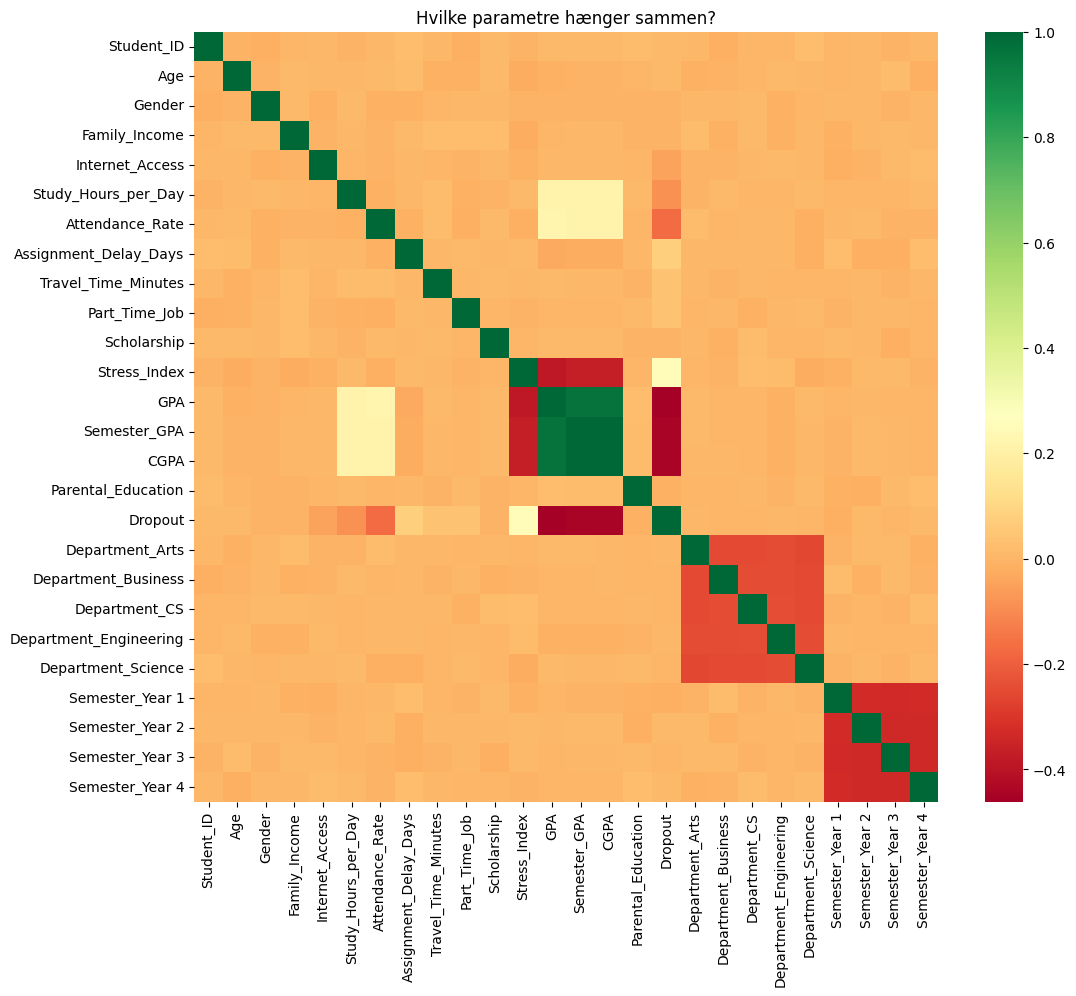

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap='RdYlGn')
plt.title('Hvilke parametre hænger sammen?')
plt.show()

In [ ]:
print(df.dtypes)


Student_ID                  int64
Age                       float64
Gender                      int64
Family_Income             float64
Internet_Access             int64
Study_Hours_per_Day       float64
Attendance_Rate           float64
Assignment_Delay_Days       int64
Travel_Time_Minutes       float64
Part_Time_Job               int64
Scholarship                 int64
Stress_Index              float64
GPA                       float64
Semester_GPA              float64
CGPA                      float64
Parental_Education        float64
Dropout                     int64
Department_Arts             int64
Department_Business         int64
Department_CS               int64
Department_Engineering      int64
Department_Science          int64
Semester_Year 1             int64
Semester_Year 2             int64
Semester_Year 3             int64
Semester_Year 4             int64
dtype: object


In [ ]:
print(f"Antal rækker i df: {len(df)}")

Antal rækker i df: 9020


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Vi fjerner Student_ID, da det bare er et løbenummer uden betydning
X = df.drop(columns=['Student_ID', 'Dropout'])
y = df['Dropout']

# Split data i træning (80%) og test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lav modellen og træn den
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Modellens præcision på test-data: {rf_model.score(X_test, y_test):.2%}")

Modellens præcision på test-data: 79.99%


/tmp/ipykernel_248/2159266495.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')


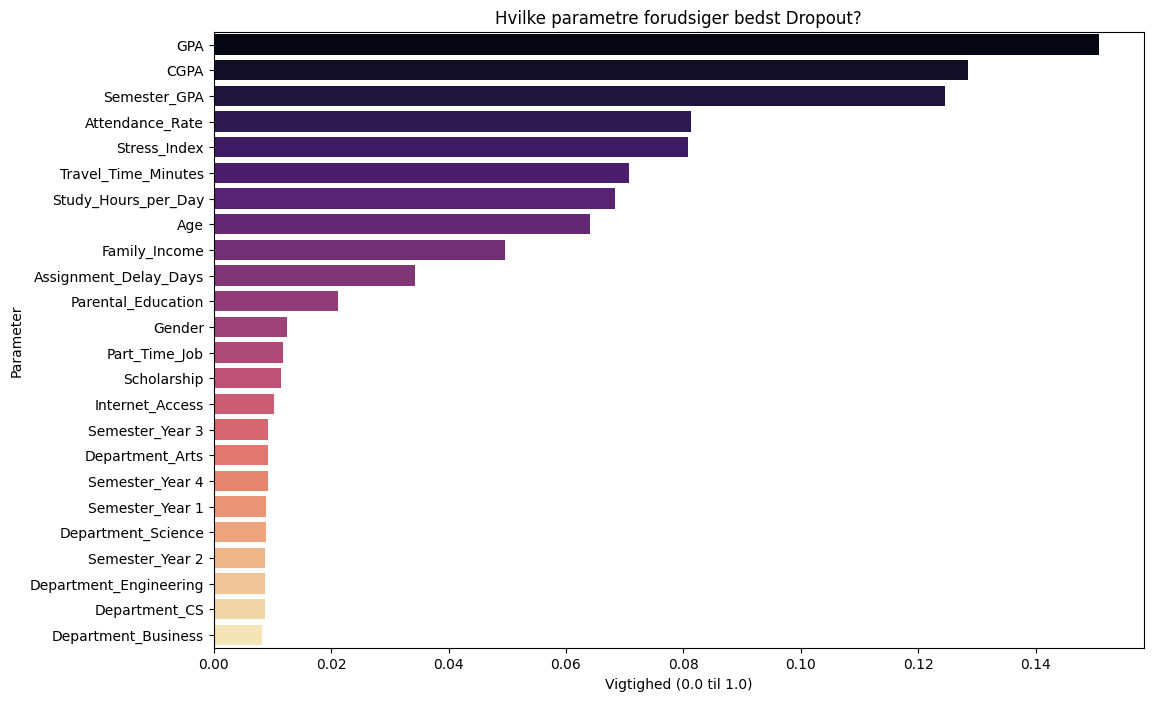

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Træk vigtigheden ud af modellen
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualiser med Seaborn
plt.figure(figsize=(12, 8))
sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')
plt.title('Hvilke parametre forudsiger bedst Dropout?')
plt.xlabel('Vigtighed (0.0 til 1.0)')
plt.ylabel('Parameter')
plt.show()

/tmp/ipykernel_346/1593466167.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_social, x='Importance', y='Feature', palette='viridis')


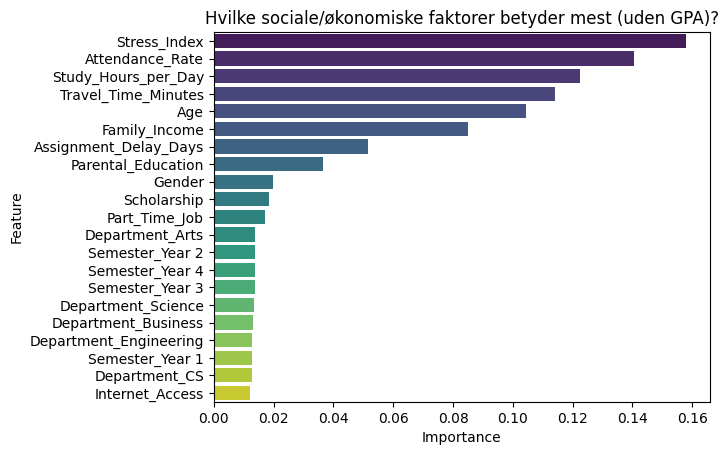

In [ ]:
# 1. Fjern karakter-leakage og ID
# Vi fjerner alle GPA-relaterede kolonner
features_to_drop = ['Student_ID', 'Dropout', 'GPA', 'CGPA', 'Semester_GPA']
X_social = df.drop(columns=features_to_drop, errors='ignore')
y = df['Dropout']

# 2. Split og træn igen
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_social, y, test_size=0.2, random_state=42)

rf_social = RandomForestClassifier(n_estimators=100, random_state=42)
rf_social.fit(X_train_s, y_train_s)

# 3. Se de NYE vigtigste parametre
importances_social = pd.DataFrame({
    'Feature': X_social.columns,
    'Importance': rf_social.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importances_social, x='Importance', y='Feature', palette='viridis')
plt.title('Hvilke sociale/økonomiske faktorer betyder mest (uden GPA)?')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Vi vælger de vigtigste faktorer fra din graf
features_for_clustering = ['Stress_Index', 'Attendance_Rate', 'Travel_Time_Minutes', 'Study_Hours_per_Day']
X_cluster = df[features_for_clustering]

# 2. Skalering er KRITISK for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Vi laver 3 grupper (clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Se hvad der kendetegner de 3 grupper
print(df.groupby('Cluster')[features_for_clustering + ['Dropout']].mean())

         Stress_Index  Attendance_Rate  Travel_Time_Minutes  \
Cluster                                                       
0            6.994270        79.643463            34.732067   
1            5.523038        87.690805            24.424486   
2            3.857227        78.643084            31.034855   

         Study_Hours_per_Day   Dropout  
Cluster                                 
0                   4.448528  0.347262  
1                   3.228323  0.199057  
2                   4.352759  0.148686  


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Vi vælger de parametre, der viste sig at være vigtigst
cluster_cols = ['Stress_Index', 'Attendance_Rate', 'Travel_Time_Minutes', 'Study_Hours_per_Day']
X_cluster = df[cluster_cols]

# Skalering (K-Means kræver at alle akser er på samme skala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Vi finder 3 naturlige grupper
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

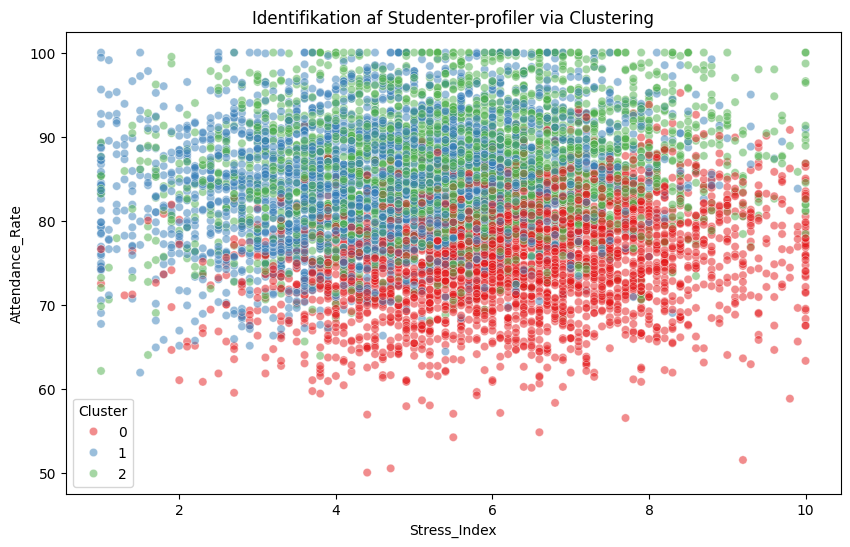

--- Profil Analyse ---
         Stress_Index  Attendance_Rate  Travel_Time_Minutes  \
Cluster                                                       
0            6.292053        75.534319            28.813924   
1            4.678745        84.424976            20.875930   
2            5.557074        86.138662            41.512413   

         Study_Hours_per_Day   Dropout  
Cluster                                 
0                   4.668401  0.318227  
1                   3.494956  0.165319  
2                   3.886193  0.221221  


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Stress_Index', y='Attendance_Rate', hue='Cluster', palette='Set1', alpha=0.5)
plt.title('Identifikation af Studenter-profiler via Clustering')
plt.show()

# Se de faktiske gennemsnit for hver gruppe
profile_summary = df.groupby('Cluster')[cluster_cols + ['Dropout']].mean()
print("--- Profil Analyse ---")
print(profile_summary)